<a href="https://www.kaggle.com/code/marydata/forecast-bmri-bank-mandiri-arima-prophet?scriptVersionId=352169234" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

#  Business Understanding

## Business Context

PT Bank Mandiri (Persero) Tbk (ticker: **BMRI.JK**) is one of the largest state-owned banks in Indonesia. Its stock is traded daily on the Indonesian market, and its price reflects both the company's performance and the broader macroeconomic dynamics of the Indonesian banking sector.

In quantitative finance, **time series forecasting** is a central challenge: it allows us to anticipate the future behavior of an asset based on its historical patterns, supporting investment, trading, and risk management decisions.

The dataset covers **5 years of daily trading data** (June 2021 – June 2026), with prices adjusted for corporate actions, making it a reliable basis for time series modeling.

## Business Objectives

- Understand the historical dynamics of BMRI.JK's closing price (trend, stationarity, temporal dependencies).
- Be able to forecast the short-term evolution of the closing price based on its historical values.
- Deliver a reliable, statistically validated forecasting model that can serve as a decision-support tool for investors or financial analysts.

## Data Science Objectives

- **Time series modeling**: build an **ARIMA (AutoRegressive Integrated Moving Average)** model to model and forecast the stock's closing price.
- **Stationarity analysis**: examine the series (trend, seasonality) and apply the necessary differencing to make it stationary.
- **Model order identification**: determine the orders p, d, q using the **Autocorrelation Function (ACF)** and **Partial Autocorrelation Function (PACF)**, following the **Box-Jenkins methodology**:
  1. Model identification (analysis, differencing, ACF/PACF)
  2. Parameter estimation (e.g., least squares)
  3. Model verification and diagnostics
  4. Iterative adjustment if needed
  5. Validation on test data (RMSE, AIC, etc.)
- **Model verification**: ensure the residuals behave like white noise (no significant structure or correlation), through:
  - the **Ljung-Box test** (absence of autocorrelation in residuals),
  - a check for **heteroscedasticity** (constant residual variance),
  - a **normality test** on residuals (Q-Q plot, Shapiro-Wilk test).

## Success Criteria

| Criterion | Description |
|---|---|
| Stationarity properly handled | The series has been made stationary through appropriate differencing (order d) |
| Justified order selection | The orders p, d, q are chosen based on a reasoned reading of the ACF/PACF plots |
| Residuals close to white noise | The final model shows no significant residual autocorrelation (Ljung-Box), stable variance (homoscedasticity), and a near-normal distribution |
| Forecasting performance | The model is evaluated on validation data using appropriate metrics (RMSE, AIC) |

### 1.5 Available Data

The dataset `BMRI_Stock_Price_5_Years_Adjusted.csv` contains the following columns:

| Column | Description |
|---|---|
| `Date` | Trading day date (format DD-MM-YYYY) |
| `Open` | Adjusted opening price (IDR) |
| `High` | Highest price reached during the session (IDR) |
| `Low` | Lowest price reached during the session (IDR) |
| `Close` | Adjusted closing price — key column for ARIMA modeling |
| `Volume` | Total number of shares traded |

- **Frequency**: daily (trading days only)
- **Period covered**: June 2021 – June 2026
- **Currency**: Indonesian Rupiah (IDR)

## Constraints and Assumptions

- The ARIMA model assumes a linear relationship between past and present values of the series; it does not necessarily capture nonlinear dynamics or sudden market shocks.
- Forecast quality strongly depends on correctly selecting the orders (p, d, q) and achieving true stationarity after differencing.
- Historical data does not guarantee future performance, especially in the event of exogenous shocks (economic crisis, regulatory decisions, etc.).

## Expected Deliverables

- A documented notebook covering: business understanding → data exploration → stationarity analysis → order identification (ACF/PACF) → ARIMA model estimation → residual verification → forecasting and evaluation.
- Visualizations: raw time series, differenced series, ACF/PACF plots, model residuals, Q-Q plot, forecast vs. actual values.
- A summary of results (selected parameters, model performance) and recommendations.

<div style="text-align: center;">
    <img src="http://www.ebc.com/upload/default/20251010/65bc8a7d2444ed2553bf7a12f2e09e21.png" width="1000">
</div>

# 1 ARIMA Model 

**ARIMA** for (AutoRegressive Integrated Moving Average) is a methode frequently used to modelise and predict a timeserie. 

## 1.1 Components of ARIMA model
it combine 3 components :
- *AR:* AutoRegressive
- *MA:* Moving Average
- *I:* Integrated or Deferenciation

## 1.2 Oder of ARIMA model
ARIMA model is defined by three order : p, d and q
- *p (Order AR) :* It is number of therm autoregressive we have to include in the model. Means that how many values in the pass are used to predicte current values
- *d (order of differenciation):* How many times do I need to differentiate
- *q (order of Moving average):* Mean that how many redusiduce terme should we used to predict current value

## 1.3 Box-Jenkins methodology
The **Box-Jenkins methodology** is an approach frequently used for modernalize the timeserie. Here is his step: 
- **identify the model** :
    * Analyse the data: examine the timeserie data, detect the trends, seasonality and anornal behavior.
    * Differenciation : if the temporelle serie presente the trends or seasonality Apply differencing to make the data stationary.
    * Identify the order : use AFC (Autocorrelation Function) graphic and PACF (Partial Autocorrelation Function) to determine the order p, d and q.
- **Model estimation** :
     Estimation parameter : Use estimation methods (such as least squares) to estimate the parameters of the ARIMA model.
- **Verification**:
    * Model diagnotic : verify if the moel ARIMA are white noise (ie not present the structure or significative correlation)
    * Adjustment: If the model does not satisfy the white noise criteria, adjust the orders of the ARIMA model and repeat the previous steps.
    * Validation: Validate model performance using validation data or by employing evaluation metrics such as Root Mean Square Error (RMSE) or the Akaike Information Criterion (AIC).

<div style="text-align: center;">
    <strong> Formula </strong> : $y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \theta_3 \varepsilon_{t-3}$
</div>
      

# 2. Import package

In [1]:
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
%matplotlib inline 

import warnings 
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller 
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.tsa.arima.model import ARIMA

# 3. Data Description 

In [2]:
data_original = pd.read_csv('/kaggle/input/datasets/yuttasihinggusti/bmri-bank-mandiri-5-year-adjusted-stock-prices/BMRI_Stock_Price_5_Years_Adjusted.csv')
data_original

,Date,Open,High,Low,Close,Volume
0,30-06-2021,2067.37,2102.71,2049.70,2085.04,146560200
1,01-07-2021,2102.71,2120.38,2085.04,2111.55,87385400
2,02-07-2021,2111.55,2129.22,2093.88,2102.71,80422400
3,05-07-2021,2111.55,2111.55,2049.70,2067.37,29242400
4,06-07-2021,2085.04,2085.04,2032.03,2040.87,56066200
...,...,...,...,...,...,...
1196,23-06-2026,4200.00,4210.00,4090.00,4120.00,248512500
1197,24-06-2026,4130.00,4180.00,3970.00,3970.00,254221600
1198,25-06-2026,3970.00,4090.00,3960.00,4000.00,275422800
1199,26-06-2026,4000.00,4040.00,3900.00,3990.00,247361000


In [3]:
data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1201 non-null   object 
 1   Open    1201 non-null   float64
 2   High    1201 non-null   float64
 3   Low     1201 non-null   float64
 4   Close   1201 non-null   float64
 5   Volume  1201 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 56.4+ KB


In [4]:
from datetime import datetime 
data_original['Date'] = pd.to_datetime(data_original['Date'], infer_datetime_format=True)
data_original

,Date,Open,High,Low,Close,Volume
0,2021-06-30,2067.37,2102.71,2049.70,2085.04,146560200
1,2021-07-01,2102.71,2120.38,2085.04,2111.55,87385400
2,2021-07-02,2111.55,2129.22,2093.88,2102.71,80422400
3,2021-07-05,2111.55,2111.55,2049.70,2067.37,29242400
4,2021-07-06,2085.04,2085.04,2032.03,2040.87,56066200
...,...,...,...,...,...,...
1196,2026-06-23,4200.00,4210.00,4090.00,4120.00,248512500
1197,2026-06-24,4130.00,4180.00,3970.00,3970.00,254221600
1198,2026-06-25,3970.00,4090.00,3960.00,4000.00,275422800
1199,2026-06-26,4000.00,4040.00,3900.00,3990.00,247361000


In [5]:
data_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1201 entries, 0 to 1200
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Date    1201 non-null   datetime64[ns]
 1   Open    1201 non-null   float64       
 2   High    1201 non-null   float64       
 3   Low     1201 non-null   float64       
 4   Close   1201 non-null   float64       
 5   Volume  1201 non-null   int64         
dtypes: datetime64[ns](1), float64(4), int64(1)
memory usage: 56.4 KB


In [6]:
data_original = data_original.reset_index()
data = data_original.set_index("Date")
data

,index,Open,High,Low,Close,Volume
Date,,,,,,
2021-06-30,0,2067.37,2102.71,2049.70,2085.04,146560200
2021-07-01,1,2102.71,2120.38,2085.04,2111.55,87385400
2021-07-02,2,2111.55,2129.22,2093.88,2102.71,80422400
2021-07-05,3,2111.55,2111.55,2049.70,2067.37,29242400
2021-07-06,4,2085.04,2085.04,2032.03,2040.87,56066200
...,...,...,...,...,...,...
2026-06-23,1196,4200.00,4210.00,4090.00,4120.00,248512500
2026-06-24,1197,4130.00,4180.00,3970.00,3970.00,254221600
2026-06-25,1198,3970.00,4090.00,3960.00,4000.00,275422800


In [7]:
data.isnull().sum()

index     0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

# 5 Step 1 : Identify model 

## 5.1 Data Analysis

### 5.1.1 Graphic representation 

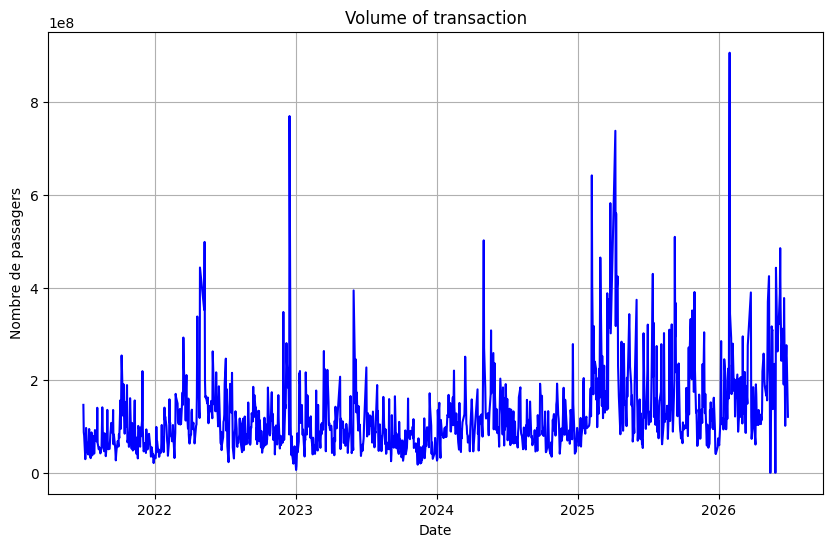

In [8]:
plt.figure(figsize=(10, 6))
plt.plot(data.index, data['Volume'], color='blue')
plt.title("Volume of transaction")
plt.xlabel('Date')
plt.ylabel('Nombre de passagers')
plt.grid(True)
plt.show()

### 5.1.2 ACF and PACF
The ACF (Autocorrelation Function) and PACF (Partial Autocorrelation Function) are two essential tools in time series analysis. They help in understanding temporal dependencies within a data series.

#### 5.1.2.1 ACF (Autocorrelation Function)
The ACF measures the correlation between a sequence and itself at different time periods. In other words, it assesses the similarity between observations based on the time lag between them.

For a lag of 'k', the ACF measures the correlation between the time series and itself shifted by 'k' periods.

For example, an ACF of 0.9 at a lag of 2 means that the data are highly similar to the data from two time periods prior.

#### 5.1.2.2 PACF (Partial Autocorrelation Function)
The PACF is a correlation that excludes the effect of intermediate terms. That is, it measures the correlation between observations at a specific interval while accounting for values ​​at shorter intervals.

For a lag of 'k', the PACF represents the correlation between the time series and itself shifted by 'k' periods, after removing the effects of lags 1 through 'k-1'.

For example, a PACF of 0.5 at a lag of 3 means that the data show a moderate level of similarity to the data from three time periods prior, after accounting for lags 1 and 2.

#### 5.1.2.3 Uses
ACF and PACF plots are commonly used to help select parameters for an ARIMA model in time series analysis. For instance, the ACF plot can be used to identify the MA (Moving Average) term of the model, while the PACF plot can help identify the AR (Autoregressive) term. 

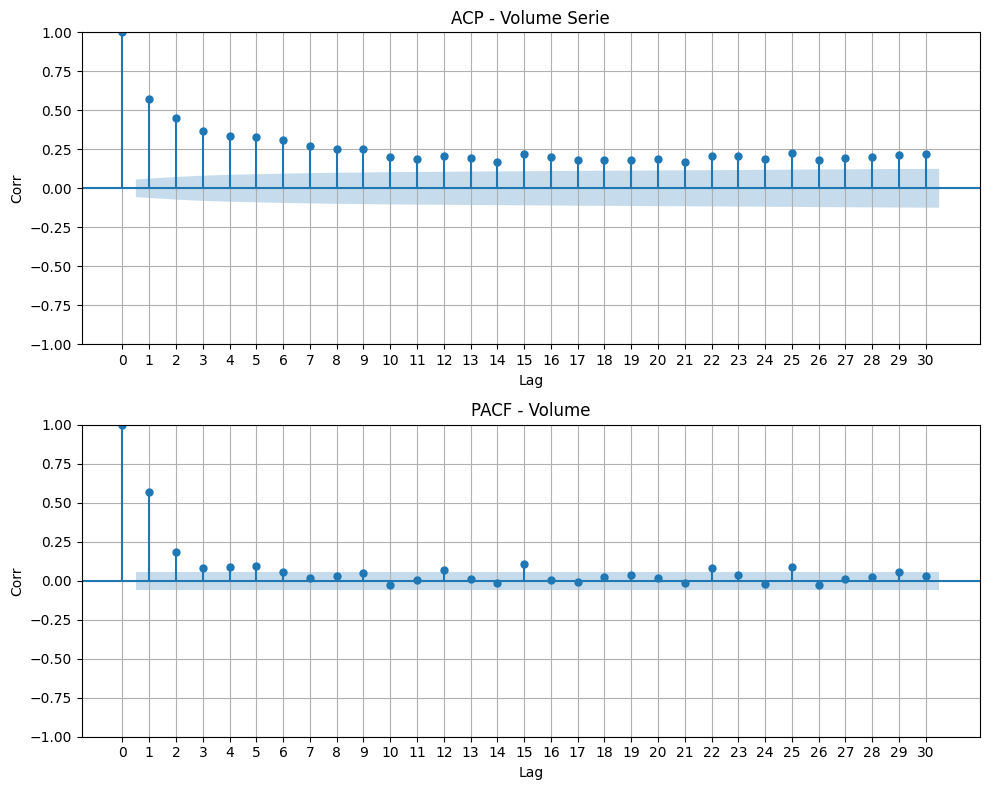

In [9]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 8))

plot_acf(data['Volume'], lags=30, zero=True, ax=ax1)
ax1.set_title('ACP - Volume Serie')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Corr')
ax1.grid(True)

ax1.set_xticks(np.arange(0, 31, 1))

plot_pacf(data['Volume'], lags = 30, zero = True, ax=ax2)
ax2.set_title('PACF - Volume')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Corr')
ax2.grid(True)

ax2.set_xticks(np.arange(0, 31, 1))

plt.tight_layout()

plt.show()

In [10]:
pip install tabulate

Note: you may need to restart the kernel to use updated packages.


In [11]:
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

serie = data['Volume']
result =  adfuller(serie)

table =[
    ['Test value', result[0]],
    ['P-value', result[1]],
    ['conclusion', 'the serie is stationnary' if result[1] < 0.05 else 'the serie is none stationnary']
]

print(tabulate(table, headers=['metric', 'values'], tablefmt='github'))

 

| metric     | values                   |
|------------|--------------------------|
| Test value | -4.947122787616555       |
| P-value    | 2.8210879058608426e-05   |
| conclusion | the serie is stationnary |


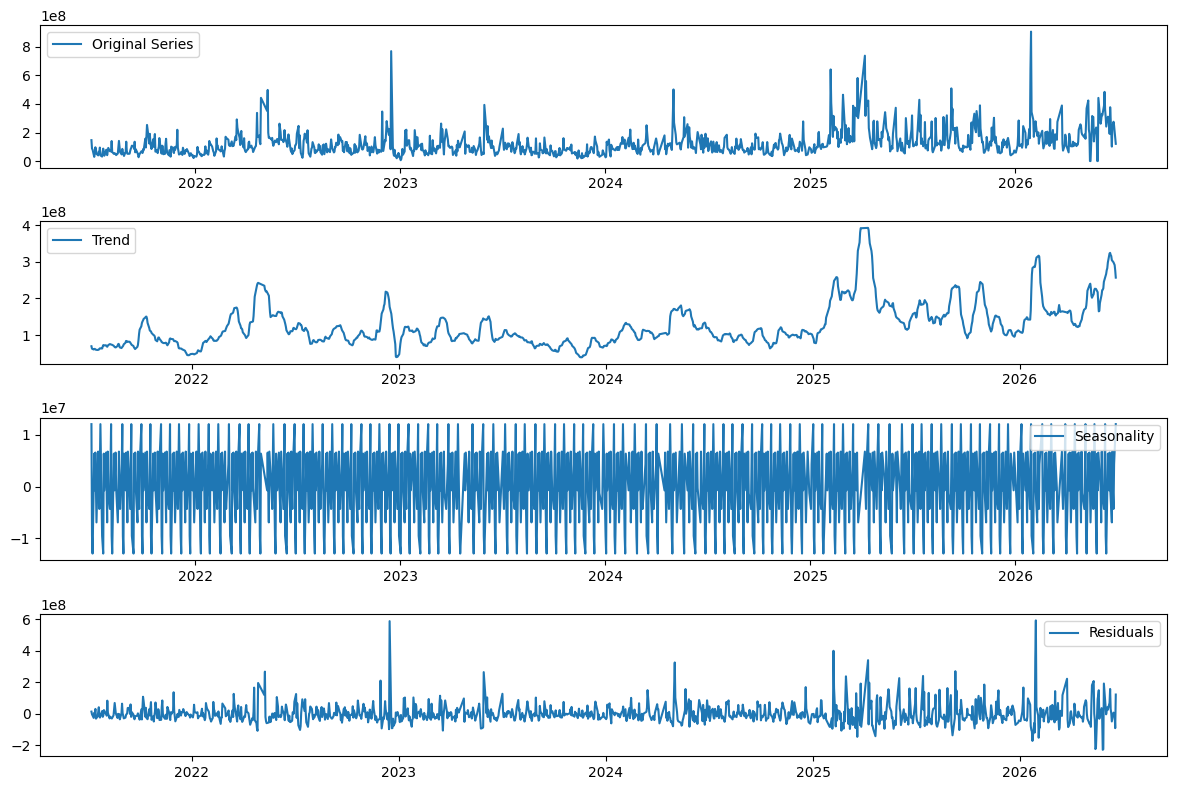

In [12]:

# Set 'period' according to your data frequency (e.g., 12 for monthly, 7 for daily)
decomposition = seasonal_decompose(data['Volume'], model='additive', period=12)

trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(data['Volume'], label='Original Series')
plt.legend(loc='best')

plt.subplot(412)
plt.plot(trend, label='Trend')
plt.legend(loc='best')

plt.subplot(413)
plt.plot(seasonal, label='Seasonality')
plt.legend(loc='best')

plt.subplot(414)
plt.plot(residual, label='Residuals')
plt.legend(loc='best')

plt.tight_layout()
plt.show()

## 5.2 Deffirenciation (stationnarisation)

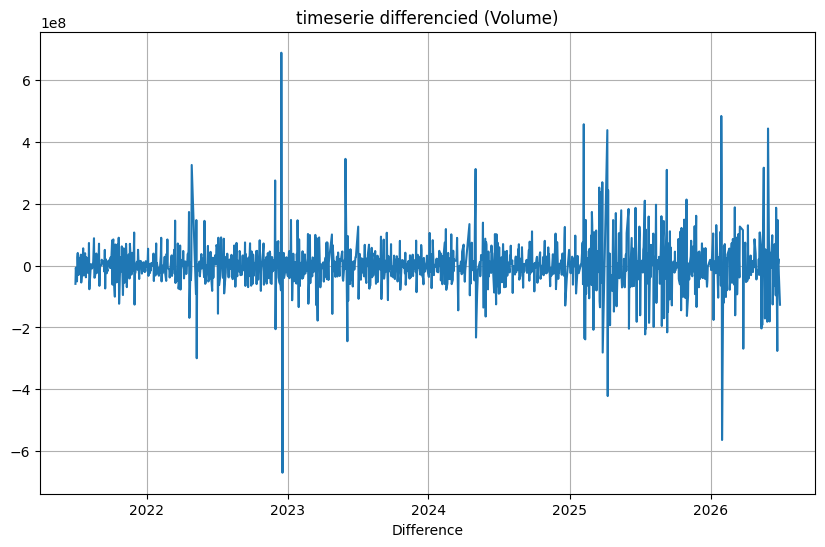

In [13]:
differenced = data['Volume'].diff().dropna()

plt.figure(figsize=(10, 6))
plt.plot(differenced)
plt.title('timeserie differencied (Volume)')
plt.xlabel('Difference')
plt.grid(True)
plt.show()

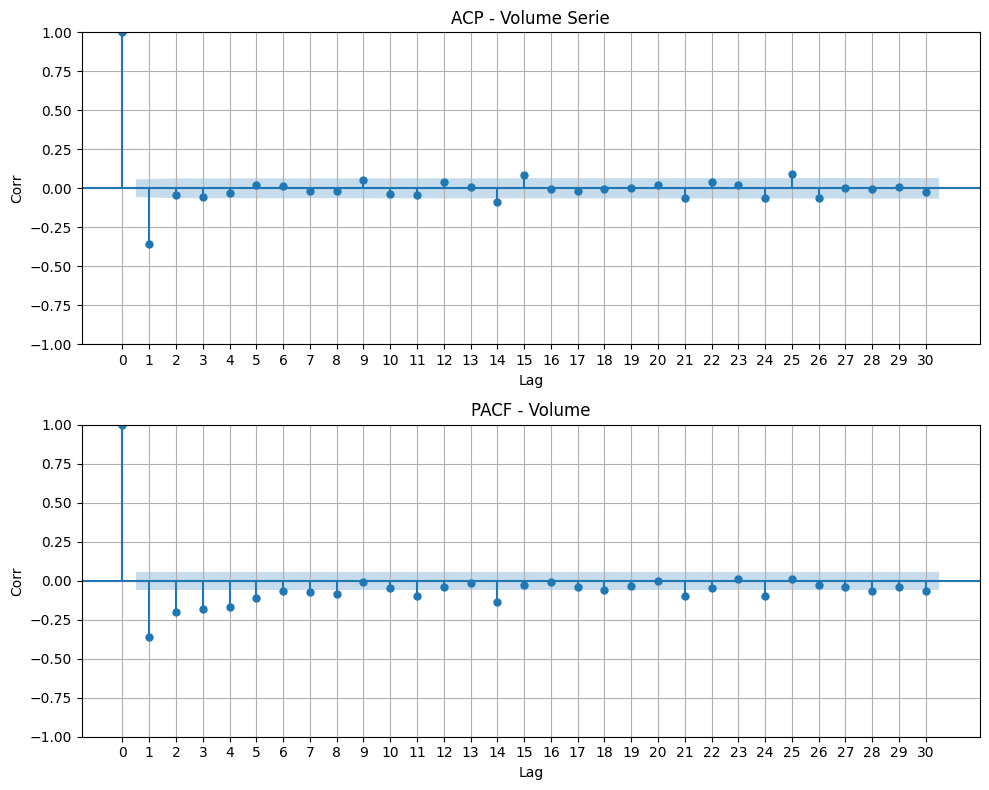

In [14]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize = (10, 8))

plot_acf(differenced, lags=30, zero=True, ax=ax1)
ax1.set_title('ACP - Volume Serie')
ax1.set_xlabel('Lag')
ax1.set_ylabel('Corr')
ax1.grid(True)

ax1.set_xticks(np.arange(0, 31, 1))

plot_pacf(differenced, lags = 30, zero = True, ax=ax2)
ax2.set_title('PACF - Volume')
ax2.set_xlabel('Lag')
ax2.set_ylabel('Corr')
ax2.grid(True)

ax2.set_xticks(np.arange(0, 31, 1))

plt.tight_layout()

plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller
from tabulate import tabulate

serie = differenced
result =  adfuller(serie)

table =[
    ['Test value', result[0]],
    ['P-value', result[1]],
    ['conclusion', 'the serie is stationnary' if result[1] < 0.05 else 'the serie is none stationnary']
]

print(tabulate(table, headers=['metric', 'values'], tablefmt='github'))

 

| metric     | values                   |
|------------|--------------------------|
| Test value | -11.891701811572718      |
| P-value    | 5.847978830195841e-22    |
| conclusion | the serie is stationnary |


## 5.3 Identification of the order p, d and q

In [16]:
p, d, q = 2, 1, 1
train_data = data['Volume'][:-15]
test_data = data['Volume'][-15:]

# 6 Model estimation

In [17]:
model = ARIMA(train_data, order=(2,1,1))
model_fit = model.fit()
print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                 Volume   No. Observations:                 1186
Model:                 ARIMA(2, 1, 1)   Log Likelihood              -23085.601
Date:                Wed, 23 Sep 2026   AIC                          46179.202
Time:                        15:00:51   BIC                          46199.512
Sample:                             0   HQIC                         46186.857
                               - 1186                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3824      0.016     24.446      0.000       0.352       0.413
ar.L2          0.0940      0.022      4.270      0.000       0.051       0.137
ma.L1         -0.9616      0.009   -108.860      0.0

# 7 Model verification 
After fitting the ARIMA model, it is crucial to check the model's residuals to ensure a good fit. Residuals represent the difference between observed values ​​and the values ​​predicted by the model. If the model is well-fitted, the residuals should behave like white noise, meaning they should be a random time series with a normal distribution, a mean of zero, and no autocorrelation. Here are some key points to verify.

## 7.1 Test de Ljung-Box
The test of Ljung-Box try the abscence of autocorrelation in the residus, we want the the residus be independants one another, a low p-value (p<0.05) indicate the proof of autocorrelation 

## 7.2 Heteroscedasticity
This refers to the situation where the variability of the prediction error (or residual) is not constant across all observations. We prefer a constant prediction error, so checking for heteroscedasticity is important. A good model should exhibit homoscedasticity—that is, constant residual variance.

## 7.3 Normality
This refers to the distribution of the residuals; in a good model, we expect the residuals to follow a normal distribution. To verify this, we can use a Q-Q plot or perform a statistical test, such as the Shapiro-Wilk test.

<Figure size 1000x500 with 0 Axes>

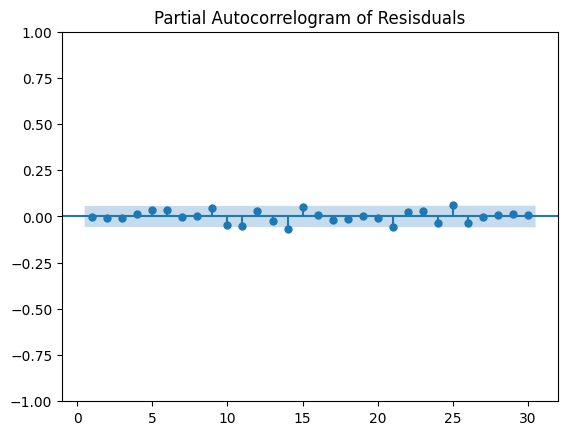

<Figure size 1000x500 with 0 Axes>

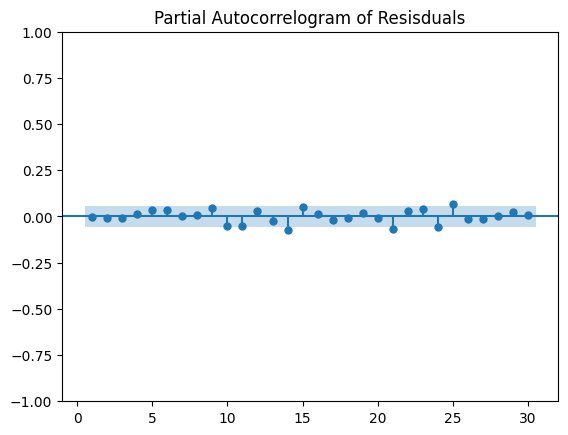

In [18]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

residuals = model_fit.resid

plt.figure(figsize=(10, 5))
plot_acf(residuals, lags=30, zero = False)
plt.title('Partial Autocorrelogram of Resisduals')
plt.show()

plt.figure(figsize=(10, 5))
plot_pacf(residuals, lags=30, zero = False)
plt.title('Partial Autocorrelogram of Resisduals')
plt.show()

# 8 Prediction

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


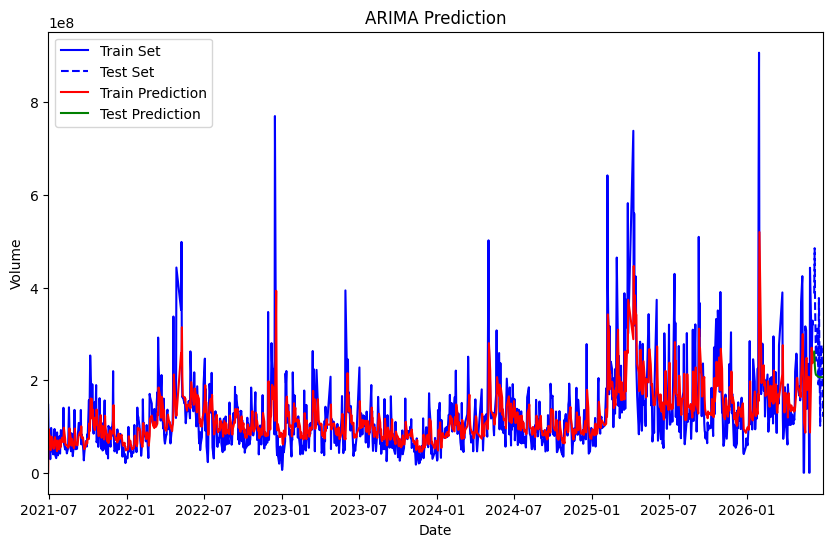

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

# In-sample predictions (Train set)
train_pred = model_fit.predict(start=0, end=len(train_data) - 1)

# Out-of-sample predictions (Test set) using steps
test_pred = model_fit.forecast(steps=len(test_data))

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(train_data.index, train_data.values, label='Train Set', color='blue')
plt.plot(test_data.index, test_data.values, label='Test Set', color='blue', linestyle='--')
plt.plot(train_data.index, train_pred.values, label='Train Prediction', color='red')
plt.plot(test_data.index, test_pred.values, label='Test Prediction', color='green')

plt.xlim(train_data.index[0], test_data.index[-1])
plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('ARIMA Prediction')

# Fixed typo in plt.legend()
plt.legend(loc='best')

plt.show()


In [20]:
train_mae = mean_absolute_error(train_data,train_pred)
train_mse = mean_squared_error(train_data, train_pred)
train_rmse = root_mean_squared_error(train_data, train_pred)
train_r2 = r2_score(train_data, train_pred)

test_mae = mean_absolute_error(test_data,test_pred)
test_mse = mean_squared_error(test_data, test_pred)
test_rmse = root_mean_squared_error(test_data, test_pred)
test_r2 = r2_score(test_data, test_pred)

performance_data = pd.DataFrame({
    'Metric' : ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train Set' : [train_mae, train_mse, train_rmse, train_r2],
    'Test Set' : [test_mae, test_mse, test_rmse, test_r2]
})

print(performance_data)

  Metric     Train Set      Test Set
0    MAE  4.359004e+07  9.265938e+07
1    MSE  4.870098e+15  1.196559e+16
2   RMSE  6.978608e+07  1.093873e+08
3     R2  3.479515e-01 -2.771186e-01


# 9 Auto Model

In [21]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 13.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [22]:
import pmdarima as pm 

train_data = data['Volume'][:-15]
test_data = data['Volume'][-15:]

model = pm.auto_arima(train_data)
print(model.summary())

                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                 1186
Model:               SARIMAX(5, 1, 5)   Log Likelihood              -23070.050
Date:                Wed, 23 Sep 2026   AIC                          46162.099
Time:                        15:01:35   BIC                          46217.952
Sample:                             0   HQIC                         46183.152
                               - 1186                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.4707      0.123     -3.837      0.000      -0.711      -0.230
ar.L2          0.0823      0.146      0.563      0.573      -0.204       0.368
ar.L3          0.4923      0.086      5.706      0.0

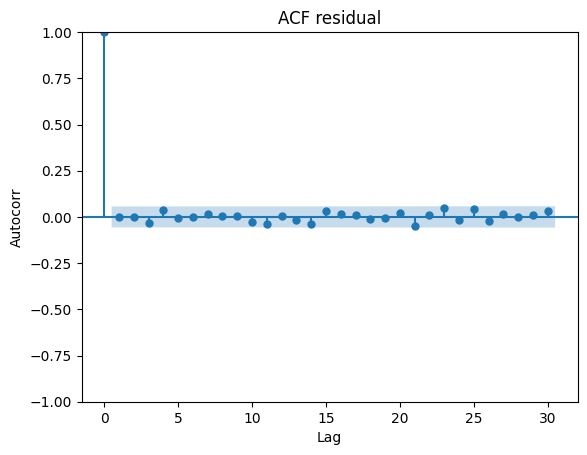

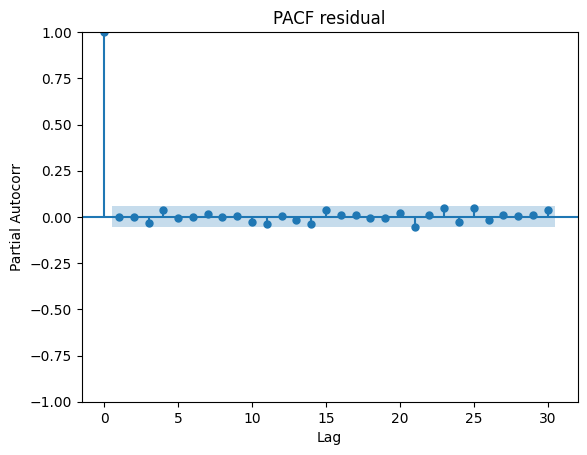

In [23]:
model.fit(train_data)
residuals = model.resid()

plot_acf(residuals, lags=30)
plt.xlabel('Lag')
plt.ylabel("Autocorr")
plt.title('ACF residual')
plt.show()

plot_pacf(residuals, lags=30)
plt.xlabel('Lag')
plt.ylabel("Partial Autocorr")
plt.title('PACF residual')
plt.show()


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


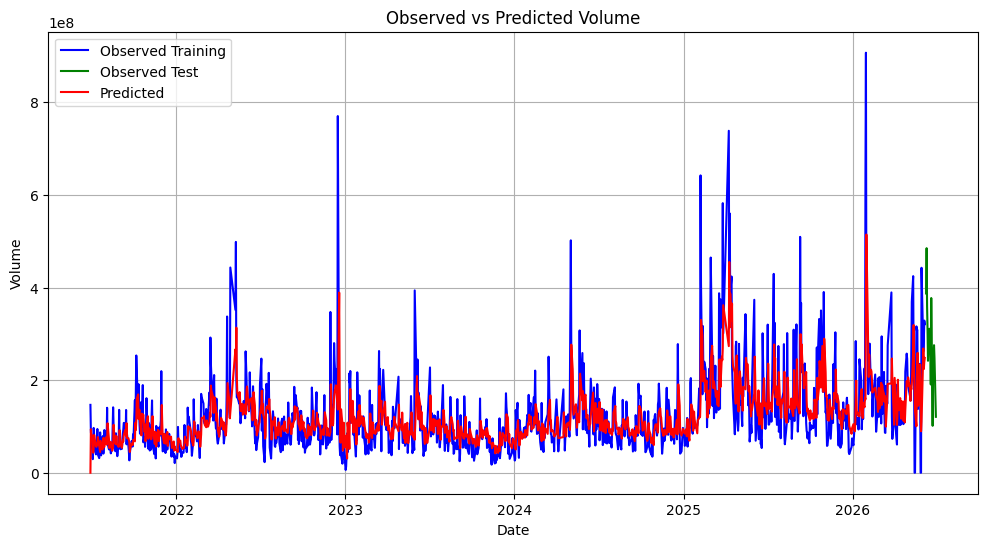

In [24]:
train_pred, train_confint = model.predict_in_sample(return_conf_int=True)

n_periods = len(test_data)
predicted = confint = model.predict(n_periods=n_periods, return_conf_in=True)

all_pred = pd.concat([pd.Series(train_pred, index=train_data.index),
                    pd.Series(predicted, index=test_data.index)],
                    axis=0)

plt.figure(figsize=(12, 6))
plt.plot(train_data, label='Observed Training', color='blue')
plt.plot(test_data, label='Observed Test', color='green')
plt.plot(all_pred, label = 'Predicted', color='red')

plt.xlabel('Date')
plt.ylabel('Volume')
plt.title('Observed vs Predicted Volume')
plt.legend()
plt.grid(True)
plt.show()

In [25]:
train_mae = mean_absolute_error(train_data,train_pred)
train_mse = mean_squared_error(train_data, train_pred)
train_rmse = root_mean_squared_error(train_data, train_pred)
train_r2 = r2_score(train_data, train_pred)

test_mae = mean_absolute_error(test_data,predicted)
test_mse = mean_squared_error(test_data, predicted)
test_rmse = root_mean_squared_error(test_data, predicted)
test_r2 = r2_score(test_data, predicted)

performance_data_ARIMA = pd.DataFrame({
    'Metric' : ['MAE', 'MSE', 'RMSE', 'R2'],
    'Train Set' : [train_mae, train_mse, train_rmse, train_r2],
    'Test Set' : [test_mae, test_mse, test_rmse, test_r2]
})

print(performance_data_ARIMA)

  Metric     Train Set      Test Set
0    MAE  4.321410e+07  9.248751e+07
1    MSE  4.760735e+15  1.168572e+16
2   RMSE  6.899808e+07  1.081005e+08
3     R2  3.625939e-01 -2.472471e-01


# 10.Same Anlaysis Using Prophet 

## 10.1 Decomposition of time series

Prophet uses an additive model where the time series $y(t)$ is expressed as:

$$y(t) = g(t) + s(t) + h(t) + \epsilon_t$$

Where,

* **Trend ($g(t)$)** is for long-term growth or decline.
* **Seasonality ($s(t)$)** includes recurring patterns such as weekly, monthly, or yearly fluctuations.
* **Holiday effects ($h(t)$)** account for irregular but predictable events, such as Black Friday or national holidays.
* **Error ($\epsilon_t$)** is the residual noise not explained by the other components.

### 10.1.1. Seasonality modeling

Seasonality is modeled using a Fourier series that permits smooth periodic functions in time-series data. It has two main forms of seasonal behavior:

* **Additive seasonality** is required when seasonal variations remain consistent in magnitude over time.
* **Multiplicative seasonality** is appropriate when seasonal fluctuations grow with the trend, such as sales volume rising with overall market growth.

Furthermore, users can also define custom seasonalities to represent unique, domain-specific patterns (e.g., quarterly promotions).

### 10.1.2. Holiday and event integration

Prophet also provides the ability to incorporate both predefined holidays and arbitrary lists of events. This is particularly advantageous when modeling business cycles, cultural holidays, or one-off events like product launches. 

One can also add unexpected events like COVID-19 as additional regressors to dynamically update forecasts. Explicit modeling of such events improves accuracy and provides insights into the impact of special dates on underlying trends.

### 10.1.3. Handling noise and outliers

Real-world data often contains noise and outliers, which can result in distorted model predictions. Prophet has robust loss functions and non-parametric trend components that make the prediction more robust to outliers in the data.

To further improve forecast stability, it is helpful to:

1. Analyze residual plots.
2. Preprocess data by winsorizing or removing anomalies.

These steps ensure that the model learns actual trends, rather than random noise.

# 10.2 Using Example
Prophet is used in many applications across Facebook for producing reliable forecasts for planning and goal setting. the prophet is found to perform better than any other approach in the majority of cases. the model fits in Stan so that you get forecasts in just a few seconds.

**NB : Stan is a state-of-the-art platform for statistical modeling and high-performance statistical computation.**

In [26]:
from prophet import Prophet

data_copy = data_original[["Date", "Volume"]].rename(columns={"Date": "ds", "Volume": "y"})

# data_copy['ds'] = pd.to_datetime(data_copy['ds'])
train_data = data_copy[:-15]
test_data = data_copy[-15:]

model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train_data)

15:01:40 - cmdstanpy - INFO - Chain [1] start processing
15:01:40 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# 4. Generate future dates and predict
future = model.make_future_dataframe(periods=len(test_data))
forecast = model.predict(future)

# 5. Extract predictions for the test period
predictions = forecast.tail(len(test_data))[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

In [28]:
merged = pd.merge(test_data, forecast[["ds", "yhat"]], on="ds", how="inner")
merged

,ds,y,yhat
0,2026-06-08,387103400,1.910293e+08
1,2026-06-09,484957600,1.949782e+08
2,2026-06-10,359183100,1.965349e+08
3,2026-06-11,308861000,1.965320e+08
4,2026-06-12,241735800,1.887557e+08
5,2026-06-15,310948900,1.707559e+08
6,2026-06-17,286865700,1.771588e+08
7,2026-06-18,190568200,1.780844e+08
8,2026-06-19,377274300,1.715300e+08


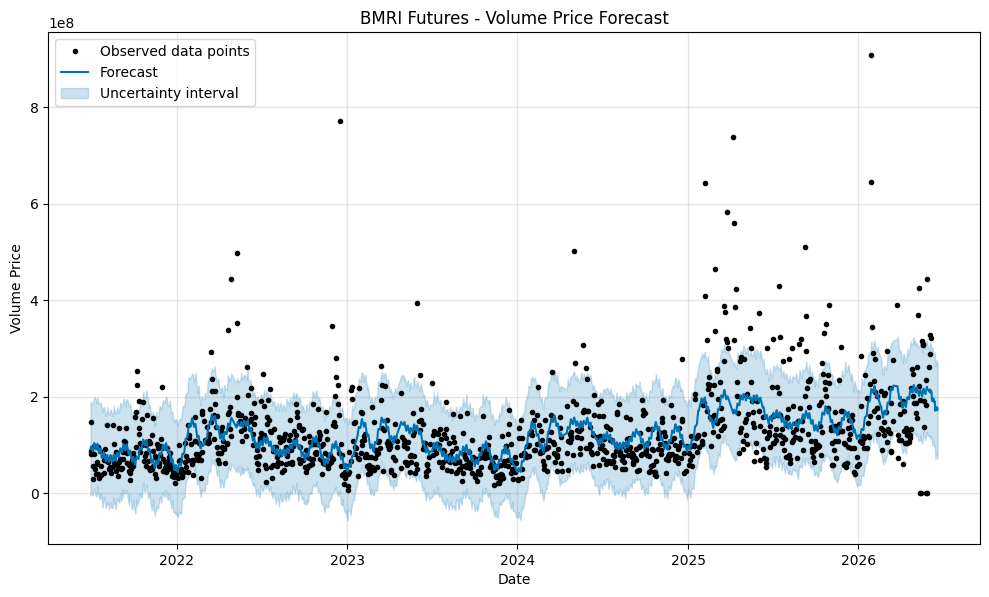

In [29]:
fig1 = model.plot(forecast)
plt.title("BMRI Futures - Volume Price Forecast")
plt.xlabel("Date")
plt.ylabel("Volume Price")
plt.legend()
plt.show()

In [30]:
# 1. Align Train set (first len(train_data) rows of forecast)
y_train_true = train_data["y"]
y_train_pred = forecast.head(len(train_data))["yhat"]

train_mae = mean_absolute_error(y_train_true, y_train_pred)
train_mse = mean_squared_error(y_train_true, y_train_pred)
train_rmse = root_mean_squared_error(y_train_true, y_train_pred)
train_r2 = r2_score(y_train_true, y_train_pred)

# 2. Align Test set (last len(test_data) rows of forecast)
y_test_true = test_data["y"]
y_test_pred = forecast.tail(len(test_data))["yhat"]

test_mae = mean_absolute_error(y_test_true, y_test_pred)
test_mse = mean_squared_error(y_test_true, y_test_pred)
test_rmse = root_mean_squared_error(y_test_true, y_test_pred)
test_r2 = r2_score(y_test_true, y_test_pred)

# 3. Build summary DataFrame
performance_data_prophet = pd.DataFrame(
    {
        "Metric": ["MAE", "MSE", "RMSE", "R2"],
        "Train Set": [train_mae, train_mse, train_rmse, train_r2],
        "Test Set": [test_mae, test_mse, test_rmse, test_r2],
    }
)
print(performance_data_ARIMA)
print('=' * 50)
print(performance_data_prophet)

  Metric     Train Set      Test Set
0    MAE  4.321410e+07  9.248751e+07
1    MSE  4.760735e+15  1.168572e+16
2   RMSE  6.899808e+07  1.081005e+08
3     R2  3.625939e-01 -2.472471e-01
  Metric     Train Set      Test Set
0    MAE  4.826262e+07  1.086261e+08
1    MSE  5.647301e+15  1.620846e+16
2   RMSE  7.514853e+07  1.273125e+08
3     R2  2.438932e-01 -7.299716e-01
